# SDSS J221958.21+003709 Fit

This notebook fetches the SDSS spectrum for `SDSS J221958.21+003709` using `astroquery`, builds data-scaled priors, and fits the spectrum with `jaxqsofit` using an `optax+nuts` workflow.

The target coordinates are parsed directly from the SDSS name to avoid relying on external name resolution.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astroquery.sdss import SDSS
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM

import jaxqsofit
from jaxqsofit import (
    ContinuumConfig,
    HostConfig,
    InferenceConfig,
    JAXQSOFit,
    LineConfig,
    Observation,
    OutputConfig,
    FitConfig,
    PreprocessingConfig,
    SpectroscopyData,
    build_default_prior_config,
)


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fetch the SDSS Spectrum

The object name `J221958.21+003709` corresponds to RA = `22:19:58.21`, Dec = `+00:37:09` in J2000 coordinates. If SDSS returns multiple spectra within the search radius, the first returned match is used.


In [ ]:
target_name = "SDSS J221958.21+003709"
# z2.173_021655.23+002755.0
# z2.314_012532.91+005948.6
target_name = "SDSS J0125332.91+005948.6"
coord = SkyCoord("22h19m58.21s", "+00d37m09s", frame="icrs")
#coord = SkyCoord("01h25m32.91s", "+00d59m48.6s", frame="icrs")

xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
if xid is None or len(xid) == 0:
    raise RuntimeError(f"No SDSS spectrum found within 5 arcsec of {target_name}.")

xid[:5]


ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,str7
21.3871410322861,0.996854158465293,1237663785280471343,4263,301,6,258,2.316139,4228,55484,948,4760565482393982976,v5_13_2


In [3]:
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb["loglam"], dtype=float)
flux = np.asarray(tb["flux"], dtype=float)
ivar = np.asarray(tb["ivar"], dtype=float)

err = np.full_like(flux, 1e-6)
good_ivar = np.isfinite(ivar) & (ivar > 0)
err[good_ivar] = 1.0 / np.sqrt(ivar[good_ivar])

z = float(sp[2].data["z"][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)

plateid = int(sp[0].header.get("plateid", 0))
mjd = int(sp[0].header.get("mjd", 0))
fiberid = int(sp[0].header.get("fiberid", 0))
sdss_filename = f"{plateid:04d}-{mjd}-{fiberid:04d}"

print(f"Target: {target_name}")
print(f"RA, Dec = {ra:.6f}, {dec:.6f} deg")
print(f"SDSS spectrum: {sdss_filename}")
print(f"N pixels: {lam.size}")
print(f"Pipeline redshift: z = {z:.5f}")


Target: SDSS J0125332.91+005948.6
RA, Dec = 21.387125, 0.996833 deg
SDSS spectrum: 4228-55484-0948
N pixels: 4615
Pipeline redshift: z = 2.31614


Text(0.5, 1.0, 'SDSS J0125332.91+005948.6')

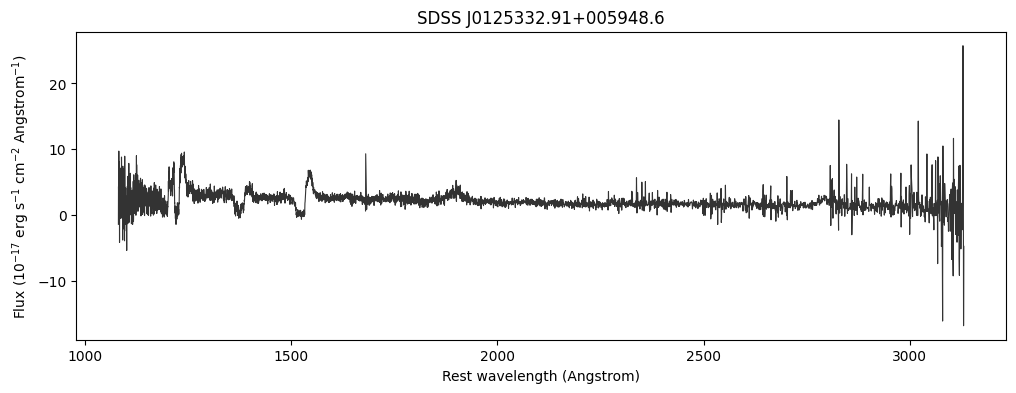

In [4]:
wave_rest = lam / (1.0 + z)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wave_rest, flux, lw=0.8, color="0.2")
ax.set_xlabel("Rest wavelength (Angstrom)")
ax.set_ylabel(r"Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$)")
ax.set_title(target_name)


## 2. Build Priors

The default priors are scaled using the rest-frame flux array. High-ionization lines are included because this is an SDSS quasar-style fit and the observed rest-frame coverage may include UV lines depending on the redshift.


In [5]:
flux_rest = flux * (1.0 + z)
prior_config = build_default_prior_config(
    flux_rest,
    include_high_ionization_lines=True,
    include_elg_narrow_lines=False,
)

fscale = np.nanmedian(np.abs(flux_rest[np.isfinite(flux_rest)]))

# Mildly informative continuum and Fe priors for a stable first pass.
prior_config.overrides["PL_slope"] = {
    "dist": "Normal",
    "loc": -1.5,
    "scale": 0.4,
}
prior_config.overrides["log_Fe_uv_norm"] = {
    "dist": "LogNormal",
    "loc": np.log(max(0.02 * fscale, 1e-12)),
    "scale": 1.0,
}
prior_config.overrides["log_Fe_op_over_uv"] = {
    "dist": "Normal",
    "loc": 0.0,
    "scale": 1.0,
}

prior_config.lines.dmu_scale_mult = 0.25
prior_config.lines.sig_scale_mult = 0.25
prior_config.lines.amp_scale_mult = 0.20


## 3. Fit with JAXQSOFit

This configuration fits a power-law continuum, Fe II, Balmer continuum, polynomial tilt, reddening, and emission lines. Host decomposition is disabled for a fast quasar fit; switch `HostConfig(enabled=True, dsps_ssp_fn="tempdata.h5")` if you want a host-galaxy component.


/Users/colinburke/research/jaxqsofit/src/jaxqsofit/core.py:2731: RuntimeWarning: Mean of empty slice.
  tmp_SN = np.array([flux[ind5100].mean() / flux[ind5100].std(), flux[ind3000].mean() / flux[ind3000].std(), flux[ind1350].mean() / flux[ind1350].std()])
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encoun

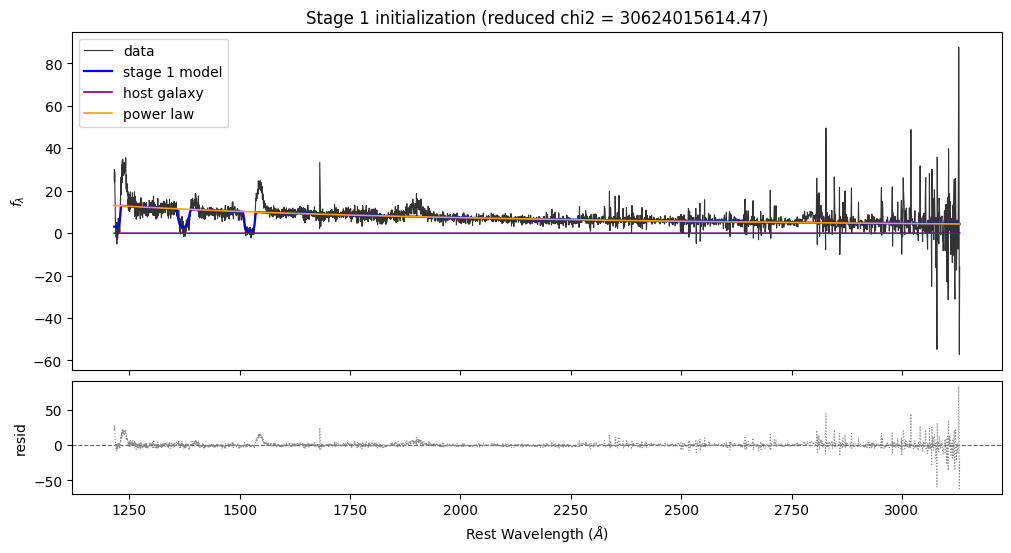

100%|██████████| 534/534 [00:06<00:00, 82.73it/s, init loss: 1501539.4582, avg. loss [495-520]: 9951.4423]   


max data        : 87.72643143297893
max total model : 25.71052472379141
max PL          : 6.983207870256463
max host        : 0.0
max FeII UV     : 0.10243556289027791
max FeII opt    : 0.0
max Balmer cont : 0.0
max lines       : 19.216957367104033
max bal_nv     : 0.0
max bal_siiv   : 0.0
max bal_civ    : 0.0


sample: 100%|██████████| 200/200 [07:07<00:00,  2.14s/it, 255 steps of size 1.98e-02. acc. prob=0.82]


max data        : 87.72643143297893
max total model : 31.89112055060762
max PL          : 11.420228706174541
max host        : 0.0
max FeII UV     : 0.1519279485034869
max FeII opt    : 0.0
max Balmer cont : 0.0
max lines       : 20.67784234087589
max bal_nv     : 0.0
max bal_siiv   : 0.0
max bal_civ    : 0.0


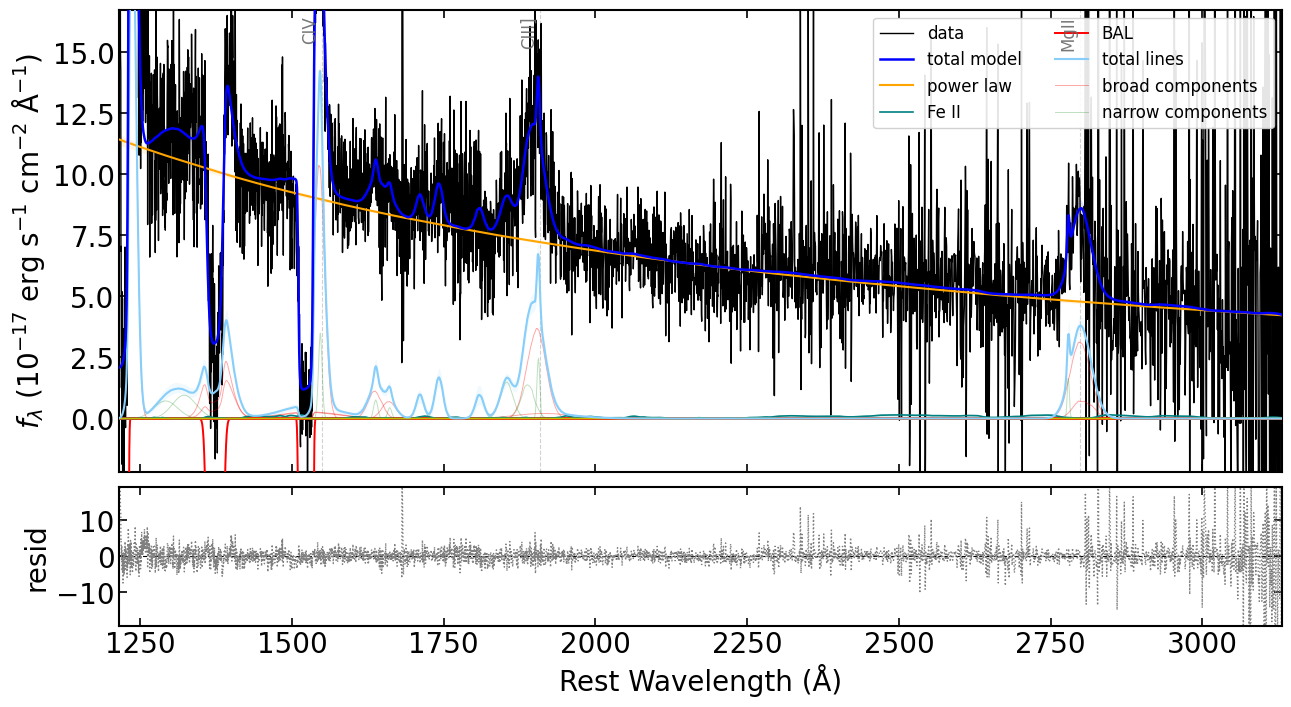

In [6]:
cfg = FitConfig(
    observation=Observation(
        object_id=sdss_filename,
        redshift=z,
        ra=ra,
        dec=dec,
        apply_mw_deredden=True,
    ),
    spectroscopy=SpectroscopyData(wave_obs=lam, fluxes=flux, errors=err),
    preprocessing=PreprocessingConfig(mask_lya_forest=True),
    continuum=ContinuumConfig(
        fit_power_law=True,
        fit_feii=True,
        fit_balmer_continuum=False,
        fit_polynomial_tilt=True,
        fit_reddening=True,
        fit_bal_absorption=True,
        polynomial_order=2,
    ),
    host=HostConfig(enabled=False, dsps_ssp_fn="tempdata.h5"),
    lines=LineConfig(enabled=True),
    inference=InferenceConfig(
        method="optax+nuts",
        map_steps=800,
        learning_rate=1e-2,
        num_warmup=100,
        num_samples=100,
        num_chains=1,
        target_accept_prob=0.9,
        plot_init=True,
    ),
    output=OutputConfig(
        output_path=".",
        save_name="sdss_j221958_003709",
        save_result=False,
        plot_fig=True,
        save_fig=False,
        show_plot=True,
    ),
    prior_config=prior_config,
)

q = JAXQSOFit(cfg)
result = q.fit()


## 4. Posterior Summary


In [7]:
mcmc = result.fitter.numpyro_mcmc
mcmc.print_summary()



                                   mean       std    median      5.0%     95.0%     n_eff     r_hat
                   Fe_op_FWHM   3060.80   1031.50   2841.79   1586.36   4444.62     17.68      1.01
                  Fe_op_shift     -0.00      0.00     -0.00     -0.00      0.00     85.93      1.00
                   Fe_uv_FWHM   2240.57    843.53   2154.29    970.03   3611.11     21.20      0.99
                   Fe_uv_norm      0.18      0.07      0.17      0.08      0.29      6.58      1.58
                  Fe_uv_shift     -0.00      0.00     -0.00     -0.00      0.00     90.24      1.01
                      PL_norm      7.03      0.28      6.98      6.70      7.31     20.97      1.03
                     PL_slope     -1.28      0.11     -1.29     -1.47     -1.13      9.89      1.08
                   add_jitter      0.24      0.03      0.24      0.18      0.30     60.82      1.02
      custom_bal_civ_covering      0.90      0.00      0.90      0.89      0.90      7.10      1.36

In [8]:
if q.numpyro_samples is None:
    print("No posterior samples found. Check cfg.inference.method.")
else:
    keys = sorted(q.numpyro_samples.keys())
    print(f"Number of posterior sample sites: {len(keys)}")
    print("First 25 sites:")
    print(keys[:25])


Number of posterior sample sites: 30
First 25 sites:
['Fe_op_FWHM', 'Fe_op_shift', 'Fe_uv_FWHM', 'Fe_uv_norm', 'Fe_uv_shift', 'PL_norm', 'PL_slope', 'add_jitter', 'custom_bal_civ_covering', 'custom_bal_civ_shape_power', 'custom_bal_civ_sigma', 'custom_bal_civ_tau_peak', 'custom_bal_nv_covering', 'custom_bal_nv_shape_power', 'custom_bal_nv_sigma', 'custom_bal_nv_tau_peak', 'custom_bal_siiv_covering', 'custom_bal_siiv_shape_power', 'custom_bal_siiv_sigma', 'custom_bal_siiv_tau_peak', 'custom_bal_v_out', 'frac_jitter', 'line_amp_group', 'line_dmu_group', 'line_sig_group']


In [9]:
resid = np.asarray(q.flux) - np.asarray(q.model_total)
sigma = np.asarray(q.err)

if q.numpyro_samples is not None:
    samples = q.numpyro_samples
    frac_j = float(np.nanmedian(np.asarray(samples.get("frac_jitter", 0.0))))
    add_j = float(np.nanmedian(np.asarray(samples.get("add_jitter", 0.0))))
    sigma = np.sqrt(sigma**2 + (frac_j * np.abs(np.asarray(q.model_total)))**2 + add_j**2)

good = np.isfinite(resid) & np.isfinite(sigma) & (sigma > 0)
norm_resid = resid[good] / sigma[good]
print(f"chi2 per fitted pixel = {np.nanmean(norm_resid**2):.3f}")
print(f"normalized residual WRMS = {np.sqrt(np.nanmean(norm_resid**2)):.3f}")


chi2 per fitted pixel = 7.518
normalized residual WRMS = 2.742


## 5. Diagnostics and Broad-Line Measurements


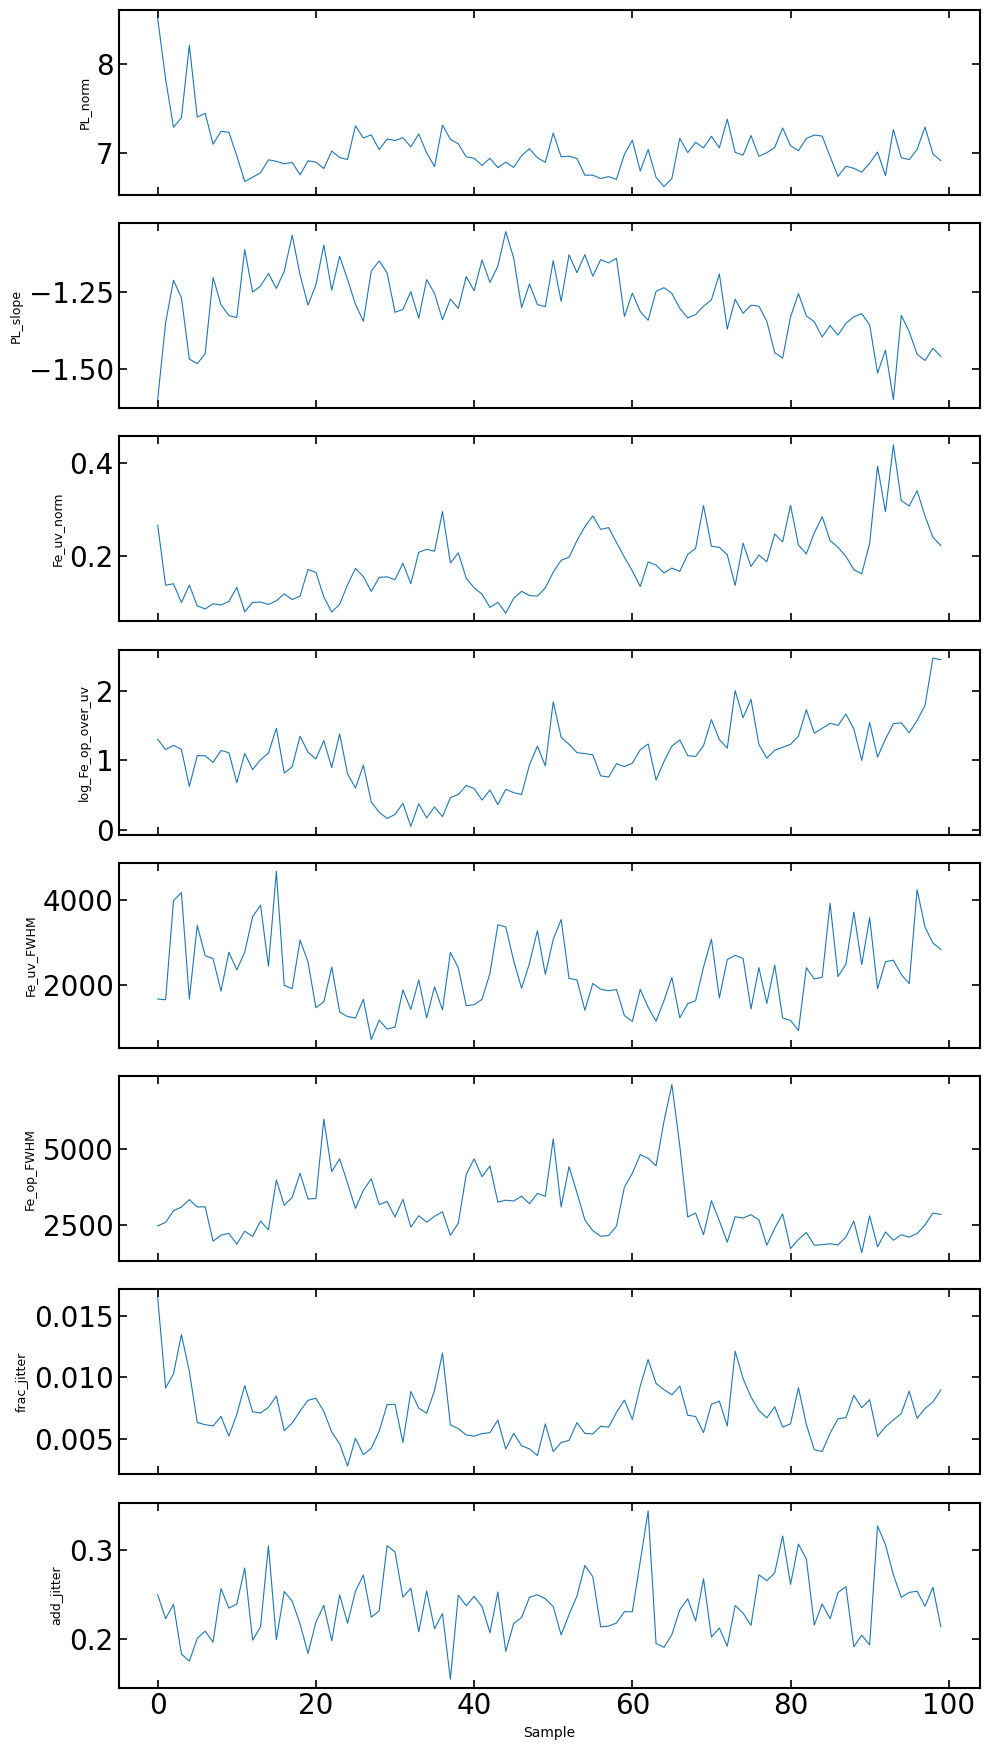

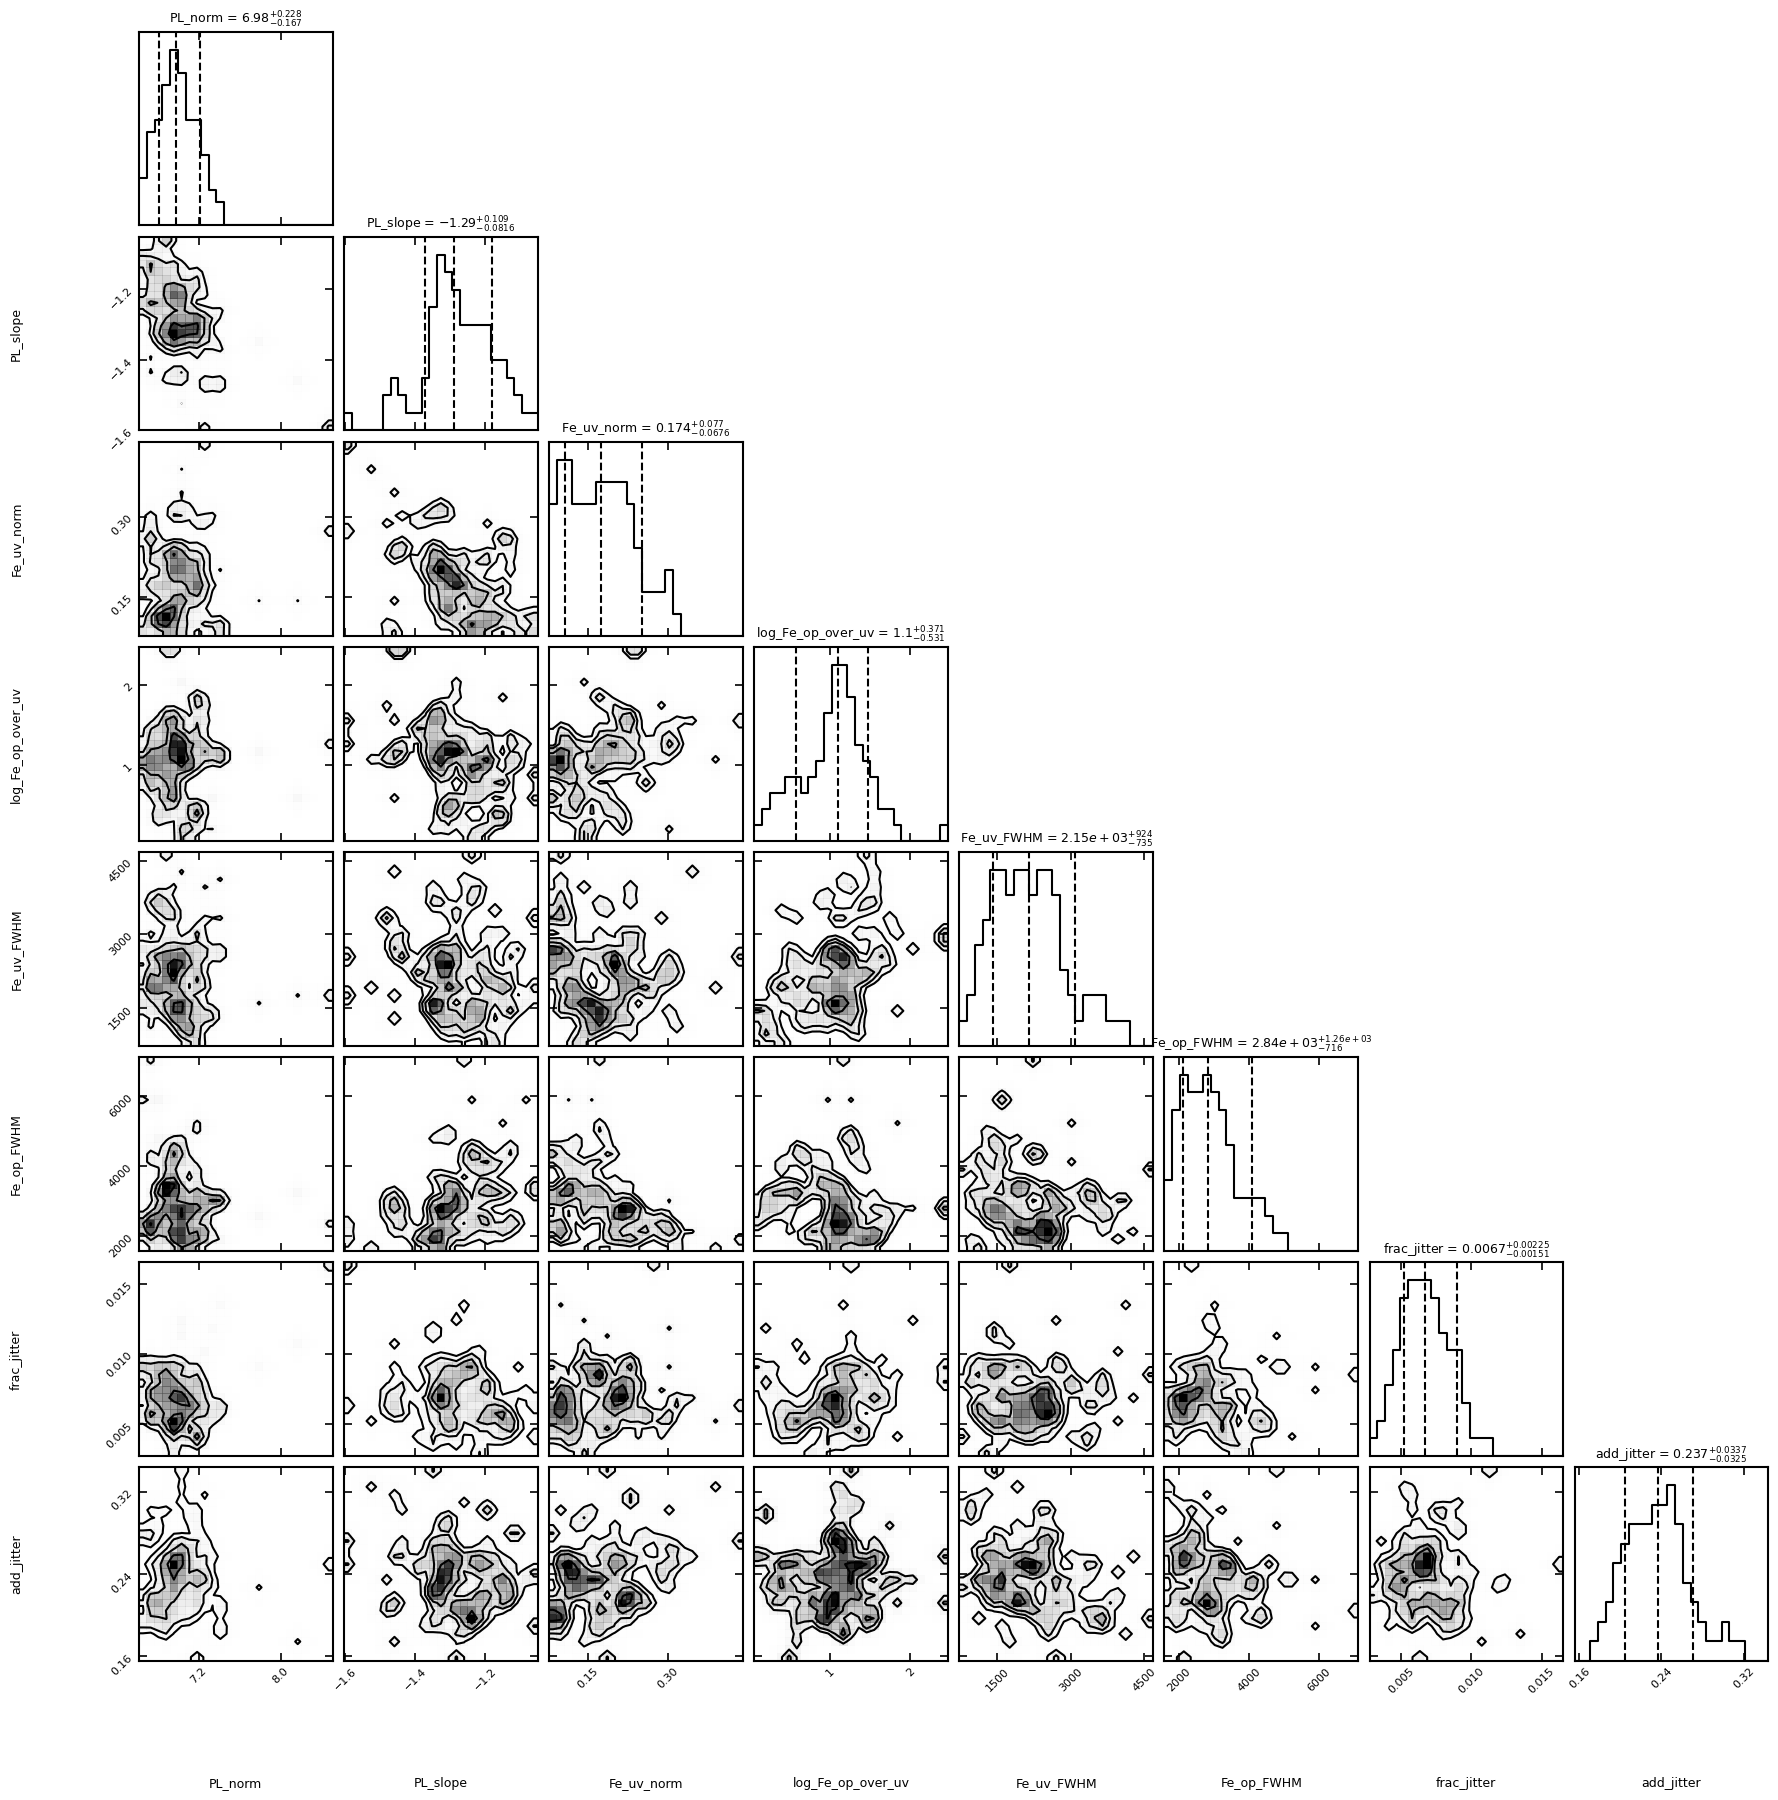

In [10]:
q.plot_mcmc_diagnostics(
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)


In [11]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def flux_to_luminosity(area_1e17, z):
    d_l_cm = cosmo.luminosity_distance(z).to(u.cm).value
    return area_1e17 * 1e-17 * 4.0 * np.pi * d_l_cm**2

if q.pred_out is None or "line_amp_per_component" not in q.pred_out:
    print("No line posterior predictive output found.")
else:
    amp_draws = np.asarray(q.pred_out["line_amp_per_component"])
    candidate_lines = ["Lya_br", "CIV_br", "CIII_br", "MgII_br", "Hb_br", "Ha_br"]
    for line_key in candidate_lines:
        fwhm_samp, logL_samp = [], []
        for i in range(amp_draws.shape[0]):
            try:
                prof = q.line_profile_from_draw(i, line_key)
            except Exception:
                continue
            fwhm, area = q.line_props(prof)
            fwhm_samp.append(fwhm)
            if np.isfinite(area) and area > 0:
                logL_samp.append(np.log10(flux_to_luminosity(area, q.z)))
            else:
                logL_samp.append(np.nan)

        if len(fwhm_samp) == 0:
            continue
        fwhm_samp = np.asarray(fwhm_samp, dtype=float)
        logL_samp = np.asarray(logL_samp, dtype=float)
        if not np.any(np.isfinite(fwhm_samp)):
            continue

        f16, f50, f84 = np.nanpercentile(fwhm_samp, [16, 50, 84])
        l16, l50, l84 = np.nanpercentile(logL_samp, [16, 50, 84])
        print(
            f"{line_key:8s}  "
            f"FWHM={f50:.1f} (+{f84-f50:.1f}/-{f50-f16:.1f}) km/s   "
            f"logL={l50:.3f} (+{l84-l50:.3f}/-{l50-l16:.3f})"
        )


CIV_br    FWHM=3660.8 (+208.5/-139.8) km/s   logL=44.021 (+0.023/-0.026)
CIII_br   FWHM=5695.4 (+655.5/-874.4) km/s   logL=43.842 (+0.069/-0.099)
MgII_br   FWHM=4143.2 (+481.5/-208.9) km/s   logL=43.826 (+0.044/-0.033)


In [ ]:
# Verify fitted BAL optical depths from the current posterior samples.
# Run this after `q = JAXQSOFit(cfg); result = q.fit()`.

C_KMS = 299792.458

samples = getattr(q, "numpyro_samples", None)
if samples is None and "result" in globals():
    samples = getattr(result, "samples", None)

if not samples:
    print("No posterior samples found on `q` or `result`.")
else:
    bal_components = [
        comp for comp in getattr(q, "_fit_custom_components", ())
        if getattr(comp, "metadata", {}).get("component_type") == "bal_absorption"
    ]
    if len(bal_components) == 0:
        print("No BAL absorption components are configured on this fit.")
    else:
        found_any = False
        wave_grid = np.asarray(q.wave, dtype=float)

        def _sample_site(comp, param_name):
            """Resolve current and legacy BAL sample-site names."""
            shared_sites = getattr(comp, "metadata", {}).get("shared_parameter_sites", {})
            if isinstance(shared_sites, dict) and param_name in shared_sites:
                return str(shared_sites[param_name])
            per_component = comp.site_name(param_name)
            if param_name == "v_out" and per_component not in samples and "custom_bal_v_out" in samples:
                return "custom_bal_v_out"
            return per_component

        for comp in bal_components:
            site_tau = _sample_site(comp, "tau_peak")
            site_covering = _sample_site(comp, "covering")
            site_v_out = _sample_site(comp, "v_out")
            site_sigma = _sample_site(comp, "sigma")
            site_shape = _sample_site(comp, "shape_power")
            required = [site_tau, site_covering, site_v_out, site_sigma, site_shape]
            missing = [key for key in required if key not in samples]
            if missing:
                print(f"{comp.output_name}: missing posterior sites: {missing}")
                continue

            found_any = True
            tau_peak = np.asarray(samples[site_tau], dtype=float).reshape(-1)
            covering = np.asarray(samples[site_covering], dtype=float).reshape(-1)
            v_out = np.asarray(samples[site_v_out], dtype=float).reshape(-1)
            sigma = np.asarray(samples[site_sigma], dtype=float).reshape(-1)
            shape_power = np.asarray(samples[site_shape], dtype=float).reshape(-1)
            n = min(tau_peak.size, covering.size, v_out.size, sigma.size, shape_power.size)
            tau_peak, covering, v_out, sigma, shape_power = [
                arr[:n] for arr in (tau_peak, covering, v_out, sigma, shape_power)
            ]

            line_lambda = float(comp.metadata["line_lambda"])
            center = line_lambda * (1.0 - v_out / C_KMS)
            x = (wave_grid[None, :] - center[:, None]) / np.maximum(sigma[:, None], 1e-6)
            tau_grid = tau_peak[:, None] * np.exp(-0.5 * np.abs(x) ** shape_power[:, None])
            transmission = 1.0 - covering[:, None] * (1.0 - np.exp(-tau_grid))
            max_tau_on_grid = np.nanmax(tau_grid, axis=1)
            min_transmission = np.nanmin(transmission, axis=1)

            def pct(x):
                return np.nanpercentile(np.asarray(x, dtype=float), [16, 50, 84])

            tau16, tau50, tau84 = pct(tau_peak)
            grid16, grid50, grid84 = pct(max_tau_on_grid)
            cov16, cov50, cov84 = pct(covering)
            tr16, tr50, tr84 = pct(min_transmission)
            v16, v50, v84 = pct(v_out)
            c16, c50, c84 = pct(center)
            s16, s50, s84 = pct(sigma)

            shared_note = " shared_v_out" if site_v_out == "custom_bal_v_out" else ""
            print(
                f"{comp.output_name:8s}{shared_note:13s}  "
                f"tau_peak={tau50:.3f} (+{tau84 - tau50:.3f}/-{tau50 - tau16:.3f})  "
                f"max_tau_grid={grid50:.3f} (+{grid84 - grid50:.3f}/-{grid50 - grid16:.3f})  "
                f"covering={cov50:.3f} (+{cov84 - cov50:.3f}/-{cov50 - cov16:.3f})  "
                f"min_T={tr50:.3f} (+{tr84 - tr50:.3f}/-{tr50 - tr16:.3f})  "
                f"v_out={v50:.0f} (+{v84 - v50:.0f}/-{v50 - v16:.0f}) km/s  "
                f"center={c50:.1f} (+{c84 - c50:.1f}/-{c50 - c16:.1f}) A  "
                f"sigma={s50:.1f} (+{s84 - s50:.1f}/-{s50 - s16:.1f}) A"
            )

        if not found_any:
            print(
                "BAL components are configured, but no complete BAL posterior sites were found. "
                "If you just changed the BAL parameterization, rerun the fit cell so `q` and "
                "`q.numpyro_samples` come from the same code version."
            )
